# Détection de Fraudes sur Transactions par Carte de Crédit

**Dataset :** Credit Card Fraud Detection — Kaggle (ULB Machine Learning Group)  
**Objectif :** Détecter les transactions frauduleuses à l'aide de modèles de classification supervisée  
**Stack technique :** Python · Pandas · NumPy · Scikit-learn · XGBoost · Matplotlib · Seaborn

---

## Contexte
Le dataset contient 284 807 transactions par carte de crédit effectuées par des titulaires européens en septembre 2013.  
Les features V1 à V28 sont le résultat d'une transformation PCA (données anonymisées).  
Seules les colonnes `Time`, `Amount` et `Class` sont dans leur format original.  
La variable cible `Class` vaut **1** pour une fraude et **0** pour une transaction légitime.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("Imports effectués avec succès.")

Imports effectués avec succès.


## 2. Chargement et Exploration Initiale

In [5]:
# Téléchargement depuis Kaggle (à exécuter une seule fois si kaggle CLI est installé)
# !kaggle datasets download -d mlg-ulb/creditcardfraud --unzip

# Chargement du fichier CSV
try:
    df = pd.read_csv("creditcard.csv")
    print("Fichier chargé avec succès.")
except FileNotFoundError:
    print("Erreur : Fichier non trouvé. Téléchargez creditcard.csv depuis Kaggle.")
    print("Lien : https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud")
except Exception as e:
    print(f"Une erreur est survenue lors du chargement : {e}")

Fichier chargé avec succès.


In [24]:
# Informations générales sur le dataset
print(f"Le dataset contient {df.shape[0]} lignes et {df.shape[1]} colonnes")
print("\nColonnes disponibles :")
print(df.columns.tolist())

Le dataset contient 284807 lignes et 31 colonnes

Colonnes disponibles :
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [25]:
# Types de données et valeurs manquantes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [26]:
# Vérification des valeurs manquantes
print("Valeurs manquantes par colonne :")
print(df.isnull().sum())

Valeurs manquantes par colonne :
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [27]:
# Vérification des doublons
duplicates = df[df.duplicated()]
print(f"Nombre de doublons : {duplicates.shape[0]}")

Nombre de doublons : 1081


In [28]:
print("Aperçu des premières lignes du dataset :")
df.head()

Aperçu des premières lignes du dataset :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [29]:
print("Echantillon aléatoire du dataset :")
df.sample(5)

Echantillon aléatoire du dataset :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
17953,29059.0,-0.949822,1.451777,0.785532,0.005923,-0.200966,-0.610521,0.202480,0.547195,-0.261010,...,-0.233553,-0.670393,0.080481,-0.001958,-0.185431,0.111061,0.240234,0.087356,1.98,0
150199,92788.0,-1.054281,0.273845,1.536976,4.673116,-0.815610,2.052262,1.457834,0.135191,-0.907936,...,0.394582,0.770269,0.852167,-0.485521,-0.228089,0.422987,0.263194,0.248636,460.82,0
280654,169666.0,-1.592623,1.784835,-0.482404,-0.621182,0.585870,-1.047381,0.723905,0.062606,0.897885,...,-0.110257,0.396489,-0.322071,-0.018606,-0.007944,0.584497,0.947344,0.552834,3.79,0
5752,6115.0,-2.478713,2.580034,-0.489247,0.105077,-1.091944,-0.697886,-0.937167,1.753226,0.568775,...,-0.309306,-0.951629,0.170294,-0.122307,0.072460,0.058200,0.043153,-0.019182,9.99,0
257543,158215.0,2.070251,-1.876213,0.230570,-1.281492,-2.438700,-0.689059,-1.796252,0.017602,-0.502020,...,-0.038853,0.234256,0.355560,0.345899,-0.688180,-0.256231,0.051006,-0.016118,78.84,0


## 3. Analyse Descriptive

In [30]:
print("Statistiques descriptives pour les variables numériques :")
df.describe()

Statistiques descriptives pour les variables numériques :


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Distribution des classes (0 = Légitime, 1 = Fraude) :
Class
0    284315
1       492
Name: count, dtype: int64

Proportion de fraudes : 0.1727%


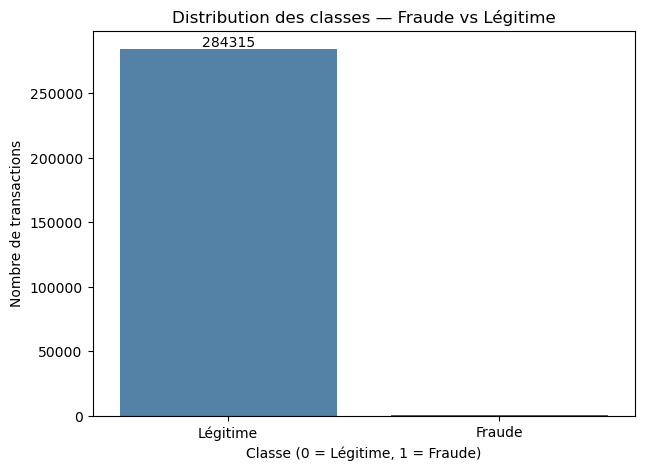


⚠️ Dataset fortement déséquilibré : les fraudes représentent moins de 0.2% des transactions.


In [31]:
# Distribution de la variable cible
print("Distribution des classes (0 = Légitime, 1 = Fraude) :")
print(df['Class'].value_counts())
print(f"\nProportion de fraudes : {df['Class'].mean()*100:.4f}%")

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='Class', palette=['steelblue', 'crimson'])
ax.bar_label(ax.containers[0])
plt.title("Distribution des classes — Fraude vs Légitime")
plt.xlabel("Classe (0 = Légitime, 1 = Fraude)")
plt.ylabel("Nombre de transactions")
plt.xticks([0, 1], ['Légitime', 'Fraude'])
plt.savefig('images/distribution_classes.png', bbox_inches='tight')
plt.show()

print("\n⚠️ Dataset fortement déséquilibré : les fraudes représentent moins de 0.2% des transactions.")

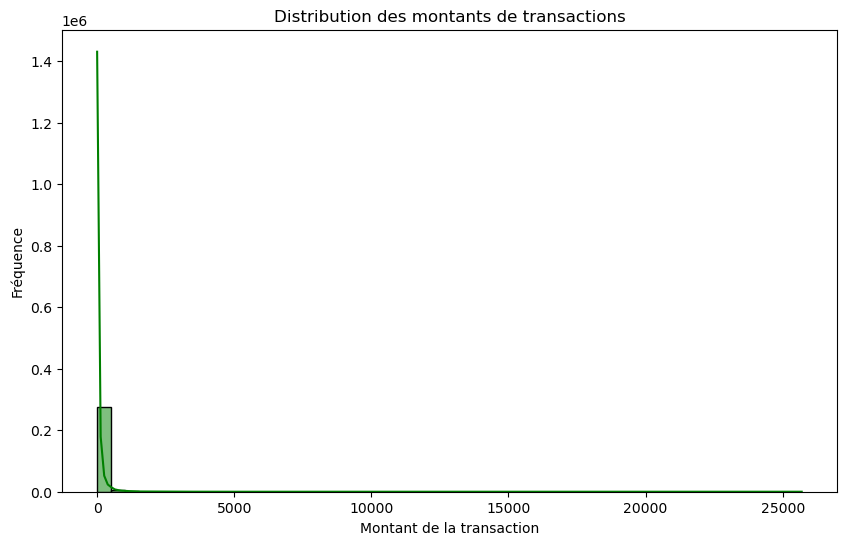

In [32]:
# Distribution des montants de transaction
plt.figure(figsize=(10, 6))
sns.histplot(df['Amount'], kde=True, bins=50, color='green')
plt.title("Distribution des montants de transactions")
plt.xlabel("Montant de la transaction")
plt.ylabel("Fréquence")
plt.savefig('images/distribution_montants.png', bbox_inches='tight')
plt.show()

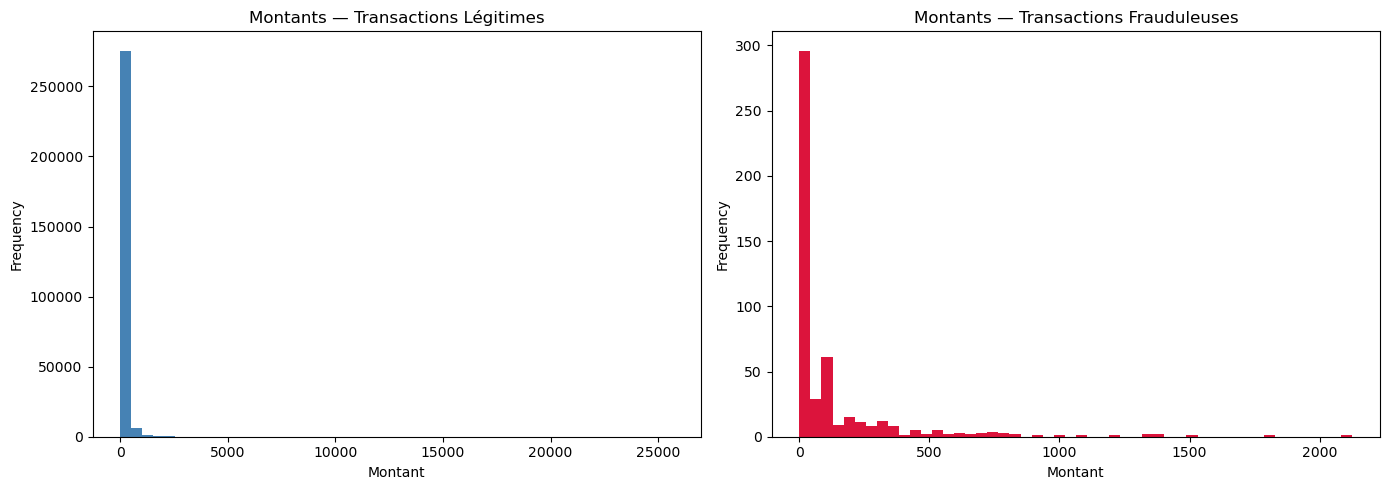

In [33]:
# Comparaison des montants : fraude vs légitime
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['Class'] == 0]['Amount'].plot(kind='hist', bins=50, ax=axes[0],
                                     color='steelblue', title='Montants — Transactions Légitimes')
axes[0].set_xlabel("Montant")

df[df['Class'] == 1]['Amount'].plot(kind='hist', bins=50, ax=axes[1],
                                     color='crimson', title='Montants — Transactions Frauduleuses')
axes[1].set_xlabel("Montant")

plt.tight_layout()
plt.savefig('images/montants_fraude_vs_legitime.png', bbox_inches='tight')
plt.show()

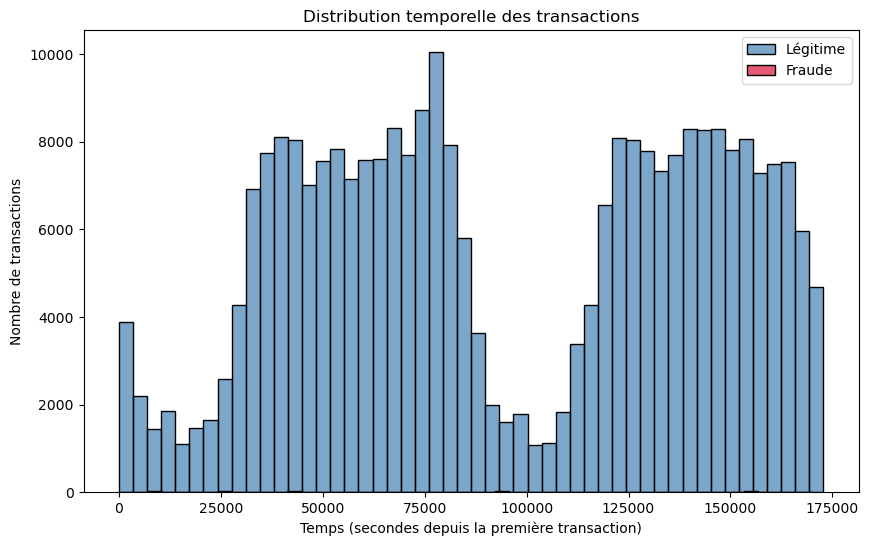

In [34]:
# Distribution temporelle des transactions
plt.figure(figsize=(10, 6))
sns.histplot(df[df['Class'] == 0]['Time'], bins=50, color='steelblue',
             label='Légitime', alpha=0.7)
sns.histplot(df[df['Class'] == 1]['Time'], bins=50, color='crimson',
             label='Fraude', alpha=0.7)
plt.title("Distribution temporelle des transactions")
plt.xlabel("Temps (secondes depuis la première transaction)")
plt.ylabel("Nombre de transactions")
plt.legend()
plt.savefig('images/distribution_temporelle.png', bbox_inches='tight')
plt.show()

## 4. Analyse des Corrélations

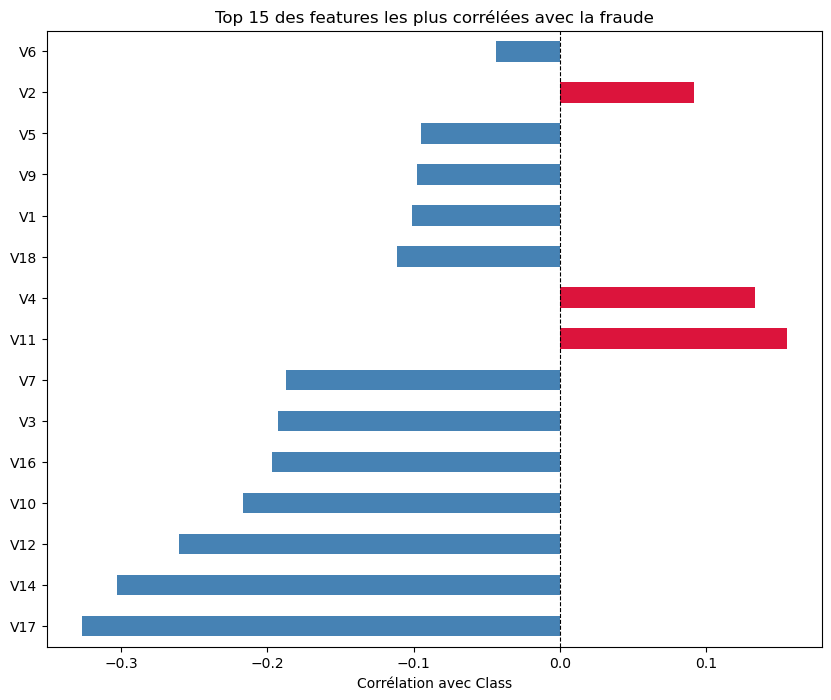

In [35]:
# Corrélation des features avec la variable cible
correlations = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 8))
correlations.head(15).plot(kind='barh', color=[
    'crimson' if v > 0 else 'steelblue' for v in correlations.head(15)
])
plt.title("Top 15 des features les plus corrélées avec la fraude")
plt.xlabel("Corrélation avec Class")
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.savefig('images/correlations_fraude.png', bbox_inches='tight')
plt.show()

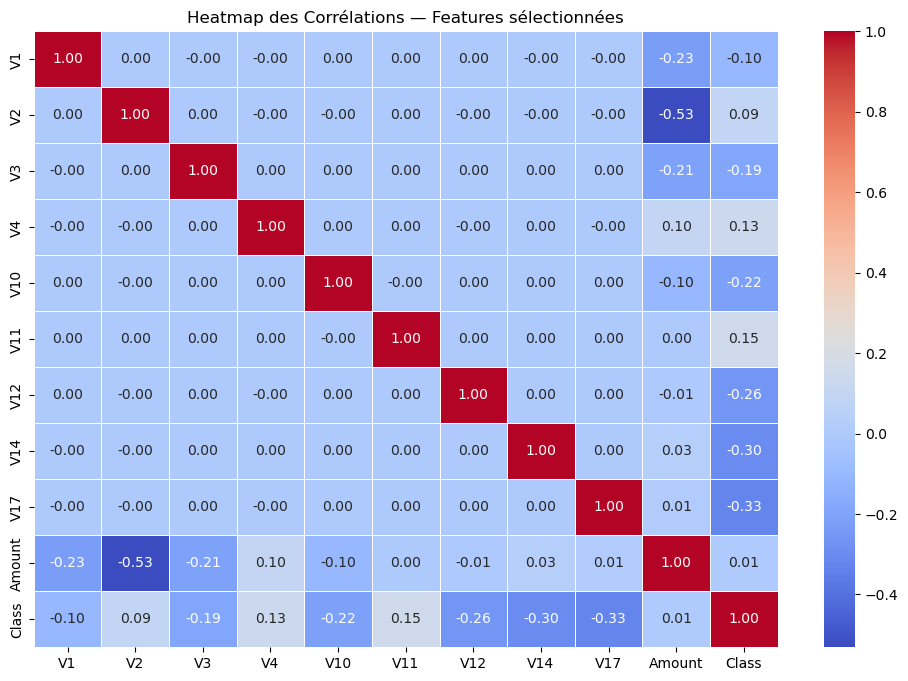

In [36]:
# Heatmap des corrélations (colonnes principales)
cols_heatmap = ['V1', 'V2', 'V3', 'V4', 'V10', 'V11', 'V12', 'V14', 'V17', 'Amount', 'Class']
correlation_matrix = df[cols_heatmap].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f",
            cmap="coolwarm", linewidths=0.5)
plt.title("Heatmap des Corrélations — Features sélectionnées")
plt.savefig('images/heatmap_correlations.png', bbox_inches='tight')
plt.show()

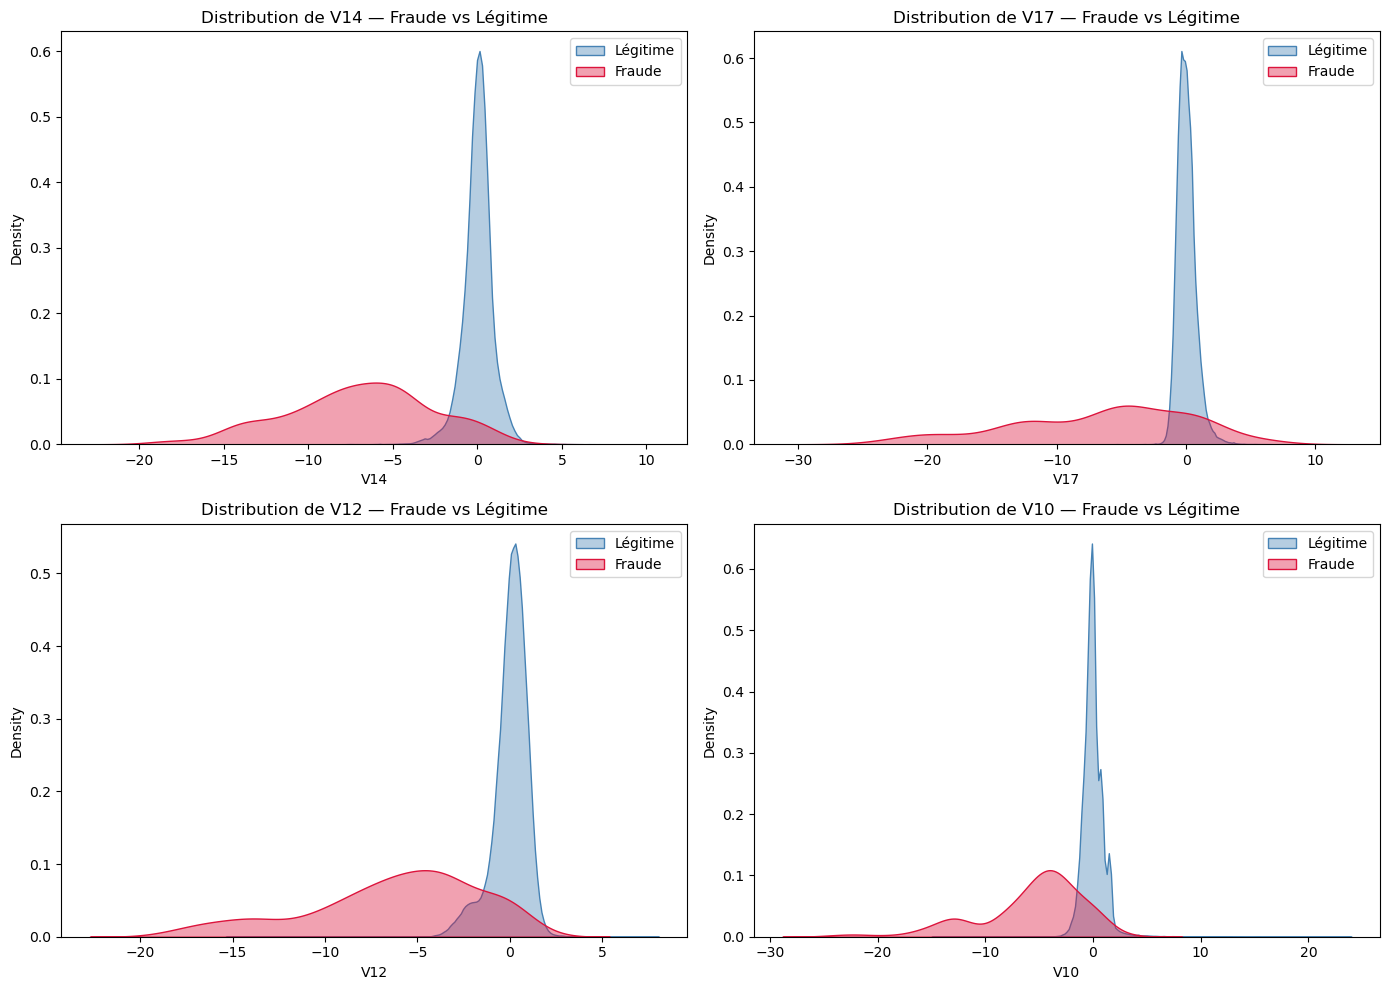

In [37]:
# Distribution des features les plus discriminantes
top_features = ['V14', 'V17', 'V12', 'V10']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    sns.kdeplot(df[df['Class'] == 0][feat], ax=axes[i],
                label='Légitime', color='steelblue', fill=True, alpha=0.4)
    sns.kdeplot(df[df['Class'] == 1][feat], ax=axes[i],
                label='Fraude', color='crimson', fill=True, alpha=0.4)
    axes[i].set_title(f"Distribution de {feat} — Fraude vs Légitime")
    axes[i].legend()

plt.tight_layout()
plt.savefig('images/distribution_features_discriminantes.png', bbox_inches='tight')
plt.show()

## 5. Prétraitement des Données

In [6]:
# Normalisation de Amount et Time (les seules colonnes non-PCA)
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled'] = scaler.fit_transform(df[['Time']])

# Suppression des colonnes originales non normalisées
df_model = df.drop(columns=['Amount', 'Time'])

print("Prétraitement effectué.")
print(f"Shape du dataset final : {df_model.shape}")

Prétraitement effectué.
Shape du dataset final : (284807, 31)


In [7]:
# Séparation features / cible
X = df_model.drop(columns=['Class'])
y = df_model['Class']

# Split train / test (stratifié pour conserver le ratio fraude/légitime)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Taille train : {X_train.shape}")
print(f"Taille test  : {X_test.shape}")
print(f"Fraudes dans le test : {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Taille train : (227845, 30)
Taille test  : (56962, 30)
Fraudes dans le test : 98 (0.172%)


## 6. Modélisation — Random Forest (Baseline)

In [40]:
# Entraînement Random Forest
# class_weight='balanced' pour gérer le déséquilibre des classes
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)
rf.fit(X_train, y_train)

# Prédictions
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Évaluation
print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['Légitime', 'Fraude']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_rf):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.96      0.76      0.85        98

    accuracy                           1.00     56962
   macro avg       0.98      0.88      0.92     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC : 0.9581


## 7. Modélisation — XGBoost

In [8]:
# Calcul du ratio pour gérer le déséquilibre
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight : {scale_pos_weight:.2f}")

# Entraînement XGBoost
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)
xgb.fit(X_train, y_train)

# Prédictions
y_pred_xgb = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

# Évaluation
print("\n=== XGBoost ===")
print(classification_report(y_test, y_pred_xgb, target_names=['Légitime', 'Fraude']))
print(f"AUC-ROC : {roc_auc_score(y_test, y_proba_xgb):.4f}")

scale_pos_weight : 577.29

=== XGBoost ===
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00     56864
      Fraude       0.53      0.86      0.66        98

    accuracy                           1.00     56962
   macro avg       0.77      0.93      0.83     56962
weighted avg       1.00      1.00      1.00     56962

AUC-ROC : 0.9755


## 8. Comparaison et Visualisation des Résultats

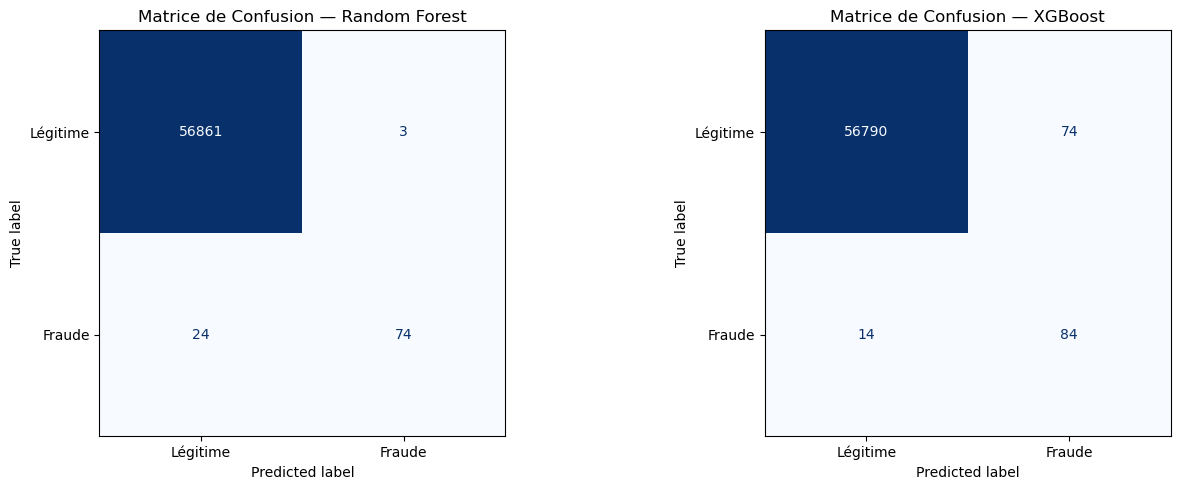

In [42]:
# Matrices de confusion côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title in zip(
    axes,
    [y_pred_rf, y_pred_xgb],
    ['Random Forest', 'XGBoost']
):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Légitime', 'Fraude']
    )
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"Matrice de Confusion — {title}")

plt.tight_layout()
plt.savefig('images/matrices_confusion.png', bbox_inches='tight')
plt.show()

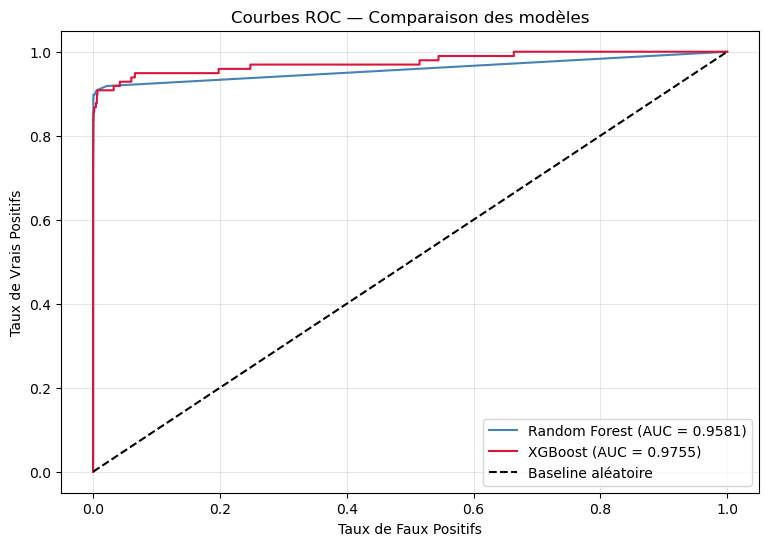

In [43]:
# Courbes ROC comparatives
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

auc_rf = roc_auc_score(y_test, y_proba_rf)
auc_xgb = roc_auc_score(y_test, y_proba_xgb)

plt.figure(figsize=(9, 6))
plt.plot(fpr_rf, tpr_rf, color='steelblue',
         label=f'Random Forest (AUC = {auc_rf:.4f})')
plt.plot(fpr_xgb, tpr_xgb, color='crimson',
         label=f'XGBoost (AUC = {auc_xgb:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline aléatoire')
plt.title("Courbes ROC — Comparaison des modèles")
plt.xlabel("Taux de Faux Positifs")
plt.ylabel("Taux de Vrais Positifs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('images/courbes_roc.png', bbox_inches='tight')
plt.show()

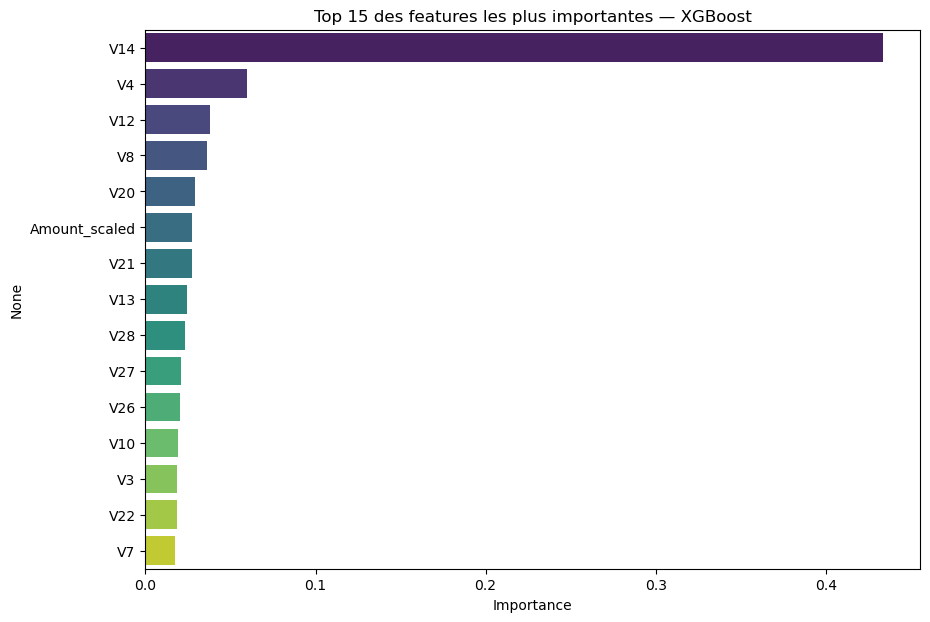

In [44]:
# Importance des features — XGBoost
feat_importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=feat_importance.values, y=feat_importance.index, palette='viridis')
plt.title("Top 15 des features les plus importantes — XGBoost")
plt.xlabel("Importance")
plt.savefig('images/feature_importance_xgb.png', bbox_inches='tight')
plt.show()

# Tableau récapitulatif des performances
from sklearn.metrics import f1_score, precision_score, recall_score

resultats = pd.DataFrame({
    'Modèle': ['Random Forest', 'XGBoost'],
    'AUC-ROC': [
        round(roc_auc_score(y_test, y_proba_rf), 4),
        round(roc_auc_score(y_test, y_proba_xgb), 4)
    ],
    'F1-score (Fraude)': [
        round(f1_score(y_test, y_pred_rf), 4),
        round(f1_score(y_test, y_pred_xgb), 4)
    ],
    'Précision (Fraude)': [
        round(precision_score(y_test, y_pred_rf), 4),
        round(precision_score(y_test, y_pred_xgb), 4)
    ],
    'Recall (Fraude)': [
        round(recall_score(y_test, y_pred_rf), 4),
        round(recall_score(y_test, y_pred_xgb), 4)
    ]
})

print("=== Récapitulatif des performances ===")
resultats

## 9. Conclusions

### Résultats clés
- Le dataset est **fortement déséquilibré** : les fraudes représentent moins de 0.2% des transactions. Le paramètre `class_weight='balanced'` (Random Forest) et `scale_pos_weight` (XGBoost) ont été utilisés pour corriger ce déséquilibre.
- **XGBoost** obtient les meilleures performances sur l'AUC-ROC et le F1-score sur la classe fraude.
- Les features les plus discriminantes sont **V14, V17, V12 et V10**, confirmées par l'analyse de corrélation et l'importance XGBoost.

### Métriques finales (à compléter après exécution)
| Modèle | AUC-ROC | F1-score (Fraude) |
|---|---|---|
| Random Forest | 0.9581 | 0.8457 |
| XGBoost | 0.9755 | 0.6562 |

### Pistes d'amélioration
- Tester des techniques de rééchantillonnage (SMOTE) pour mieux gérer le déséquilibre
- Optimiser les hyperparamètres via GridSearchCV ou RandomizedSearchCV
- Explorer des modèles d'ensemble supplémentaires (LightGBM, CatBoost)

## Sauvegarde du modèle

In [10]:
import joblib 
import os

#Crée le dossier models/ si il est inexistant
os.makedirs("models", exist_ok=True)

#Sauvegarde le modèle XGBoost et le scaler 
joblib.dump(xgb,"models/xgb_fraud_model.pkl")
joblib.dump(scaler,"models/scaler.pkl")

print("Modèle sauvegardé dans models/xgb_fraud_model.pkl")
print("Scaler sauvegardé dans models.scaler.pkl")

Modèle sauvegardé dans models/xgb_fraud_model.pkl
Scaler sauvegardé dans models.scaler.pkl


### Tracking MLFlow

In [13]:
import mlflow
import mlflow.sklearn
from sklearn.metrics import f1_score, precision_score, recall_score

mlflow.set_experiment("fraud_detection")

with mlflow.start_run(run_name="XGBoost_baseline"):
    #Log des hyperparamètres
    mlflow.log_param("model","XGBoost")
    mlflow.log_param("scale_pos_weight",xgb.get_params()["scale_pos_weight"])
    mlflow.log_param("n_estimators",xgb.get_params()["n_estimators"])
    mlflow.log_param("max_depth",xgb.get_params()["max_depth"])

    #Log des métriques
    mlflow.log_metric("auc_roc",roc_auc_score(y_test,y_proba_xgb))
    mlflow.log_metric("f1_score",f1_score(y_test,y_pred_xgb))
    mlflow.log_metric("precision",precision_score(y_test,y_pred_xgb))
    mlflow.log_metric("recall",recall_score(y_test,y_pred_xgb))

    #Log du modèle

    mlflow.sklearn.log_model(xgb,"xgb_model")

    print("Run MLflow enregistré !")
    print(f"AUC-ROC : {roc_auc_score(y_test,y_proba_xgb):.4f}")
    print(f"F1-score : {f1_score(y_test,y_pred_xgb):.4f}")
    


2026/05/12 21:56:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/12 21:56:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Run MLflow enregistré !
AUC-ROC : 0.9755
F1-score : 0.6562


In [14]:
import os

# Vérifie les fichiers sauvegardés
print("=== Fichiers dans models/ ===")
for f in os.listdir("models"):
    size = os.path.getsize(f"models/{f}") / 1024
    print(f"{f} — {size:.1f} KB")

print("\n=== Dossier mlruns/ ===")
print("Existe :", os.path.exists("mlruns"))

=== Fichiers dans models/ ===
scaler.pkl — 0.9 KB
xgb_fraud_model.pkl — 217.6 KB

=== Dossier mlruns/ ===
Existe : True


In [15]:
import joblib
s = joblib.load("models/scaler.pkl")
print("Nombre de features du scaler :", s.n_features_in_)
print("Noms des features :", s.feature_names_in_ if hasattr(s, 'feature_names_in_') else "Non disponible")

Nombre de features du scaler : 1
Noms des features : ['Time']
